In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/mushroom_cleaned.csv')

In [ ]:
df.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54035 entries, 0 to 54034
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cap-diameter     54035 non-null  int64  
 1   cap-shape        54035 non-null  int64  
 2   gill-attachment  54035 non-null  int64  
 3   gill-color       54035 non-null  int64  
 4   stem-height      54035 non-null  float64
 5   stem-width       54035 non-null  int64  
 6   stem-color       54035 non-null  int64  
 7   season           54035 non-null  float64
 8   class            54035 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.7 MB


In [ ]:
df.describe()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
count,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000
mean,567.257204,4.000315,2.142056,7.329509,0.759110,1051.081299,8.418062,0.952163,0.549181
std,359.883763,2.160505,2.228821,3.200266,0.650969,782.056076,3.262078,0.305594,0.497580
min,0.000000,0.000000,0.000000,0.000000,0.000426,0.000000,0.000000,0.027372,0.000000
25%,289.000000,2.000000,0.000000,5.000000,0.270997,421.000000,6.000000,0.888450,0.000000
50%,525.000000,5.000000,1.000000,8.000000,0.593295,923.000000,11.000000,0.943195,1.000000
75%,781.000000,6.000000,4.000000,10.000000,1.054858,1523.000000,11.000000,0.943195,1.000000
max,1891.000000,6.000000,6.000000,11.000000,3.835320,3569.000000,12.000000,1.804273,1.000000


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isnull().sum()

,0
cap-diameter,0
cap-shape,0
gill-attachment,0
gill-color,0
stem-height,0
stem-width,0
stem-color,0
season,0
class,0


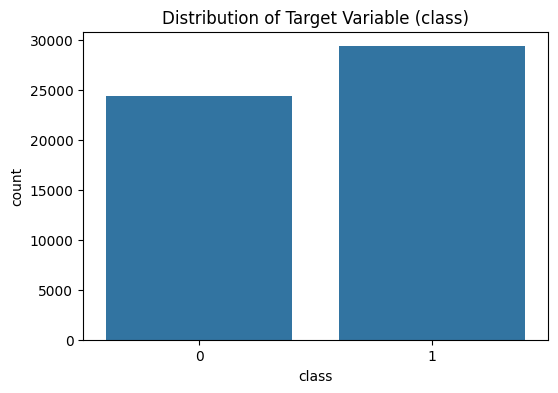

In [ ]:
plt.figure(figsize = (6,4))
sns.countplot(x = df['class'],data = df)
plt.title('Distribution of Target Variable (class)')
plt.show()

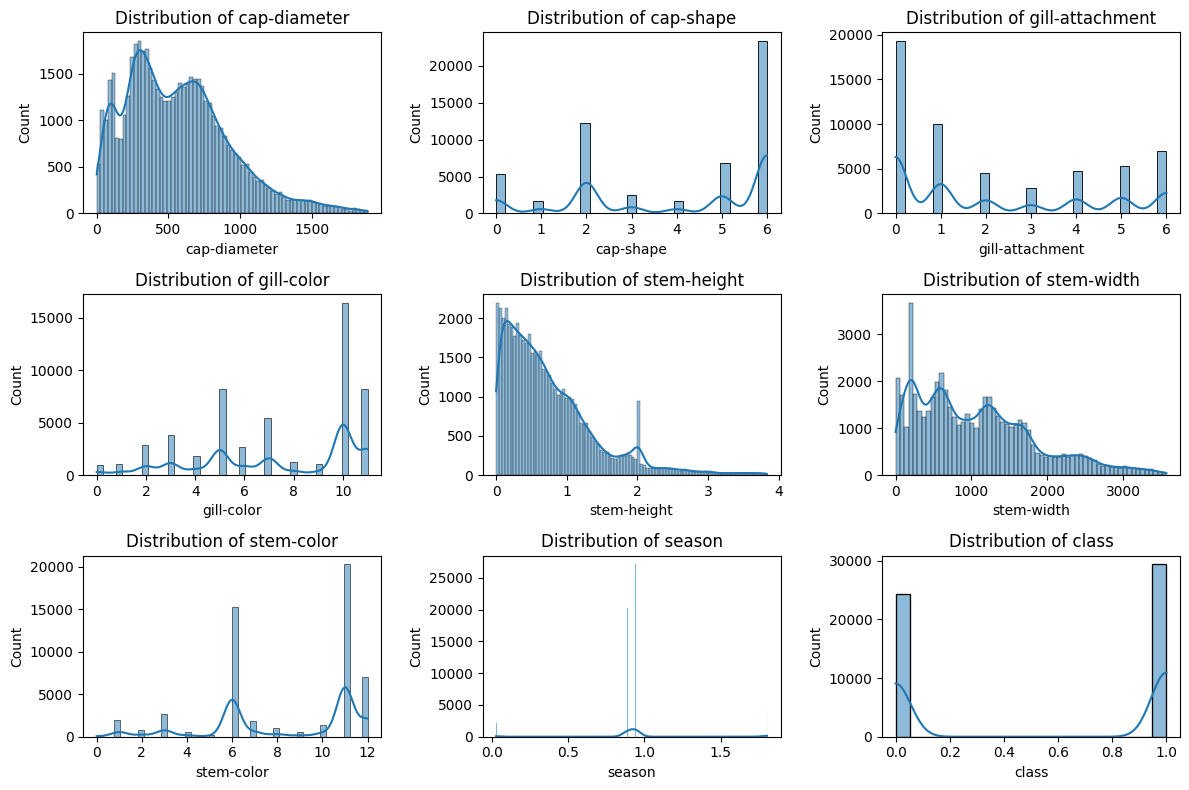

In [ ]:
plt.figure(figsize = (12,8))
for i,col in enumerate(df.columns):
  if df[col].dtype != 'object':
    plt.subplot(3,3,i+1)
    sns.histplot(df[col],kde = True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

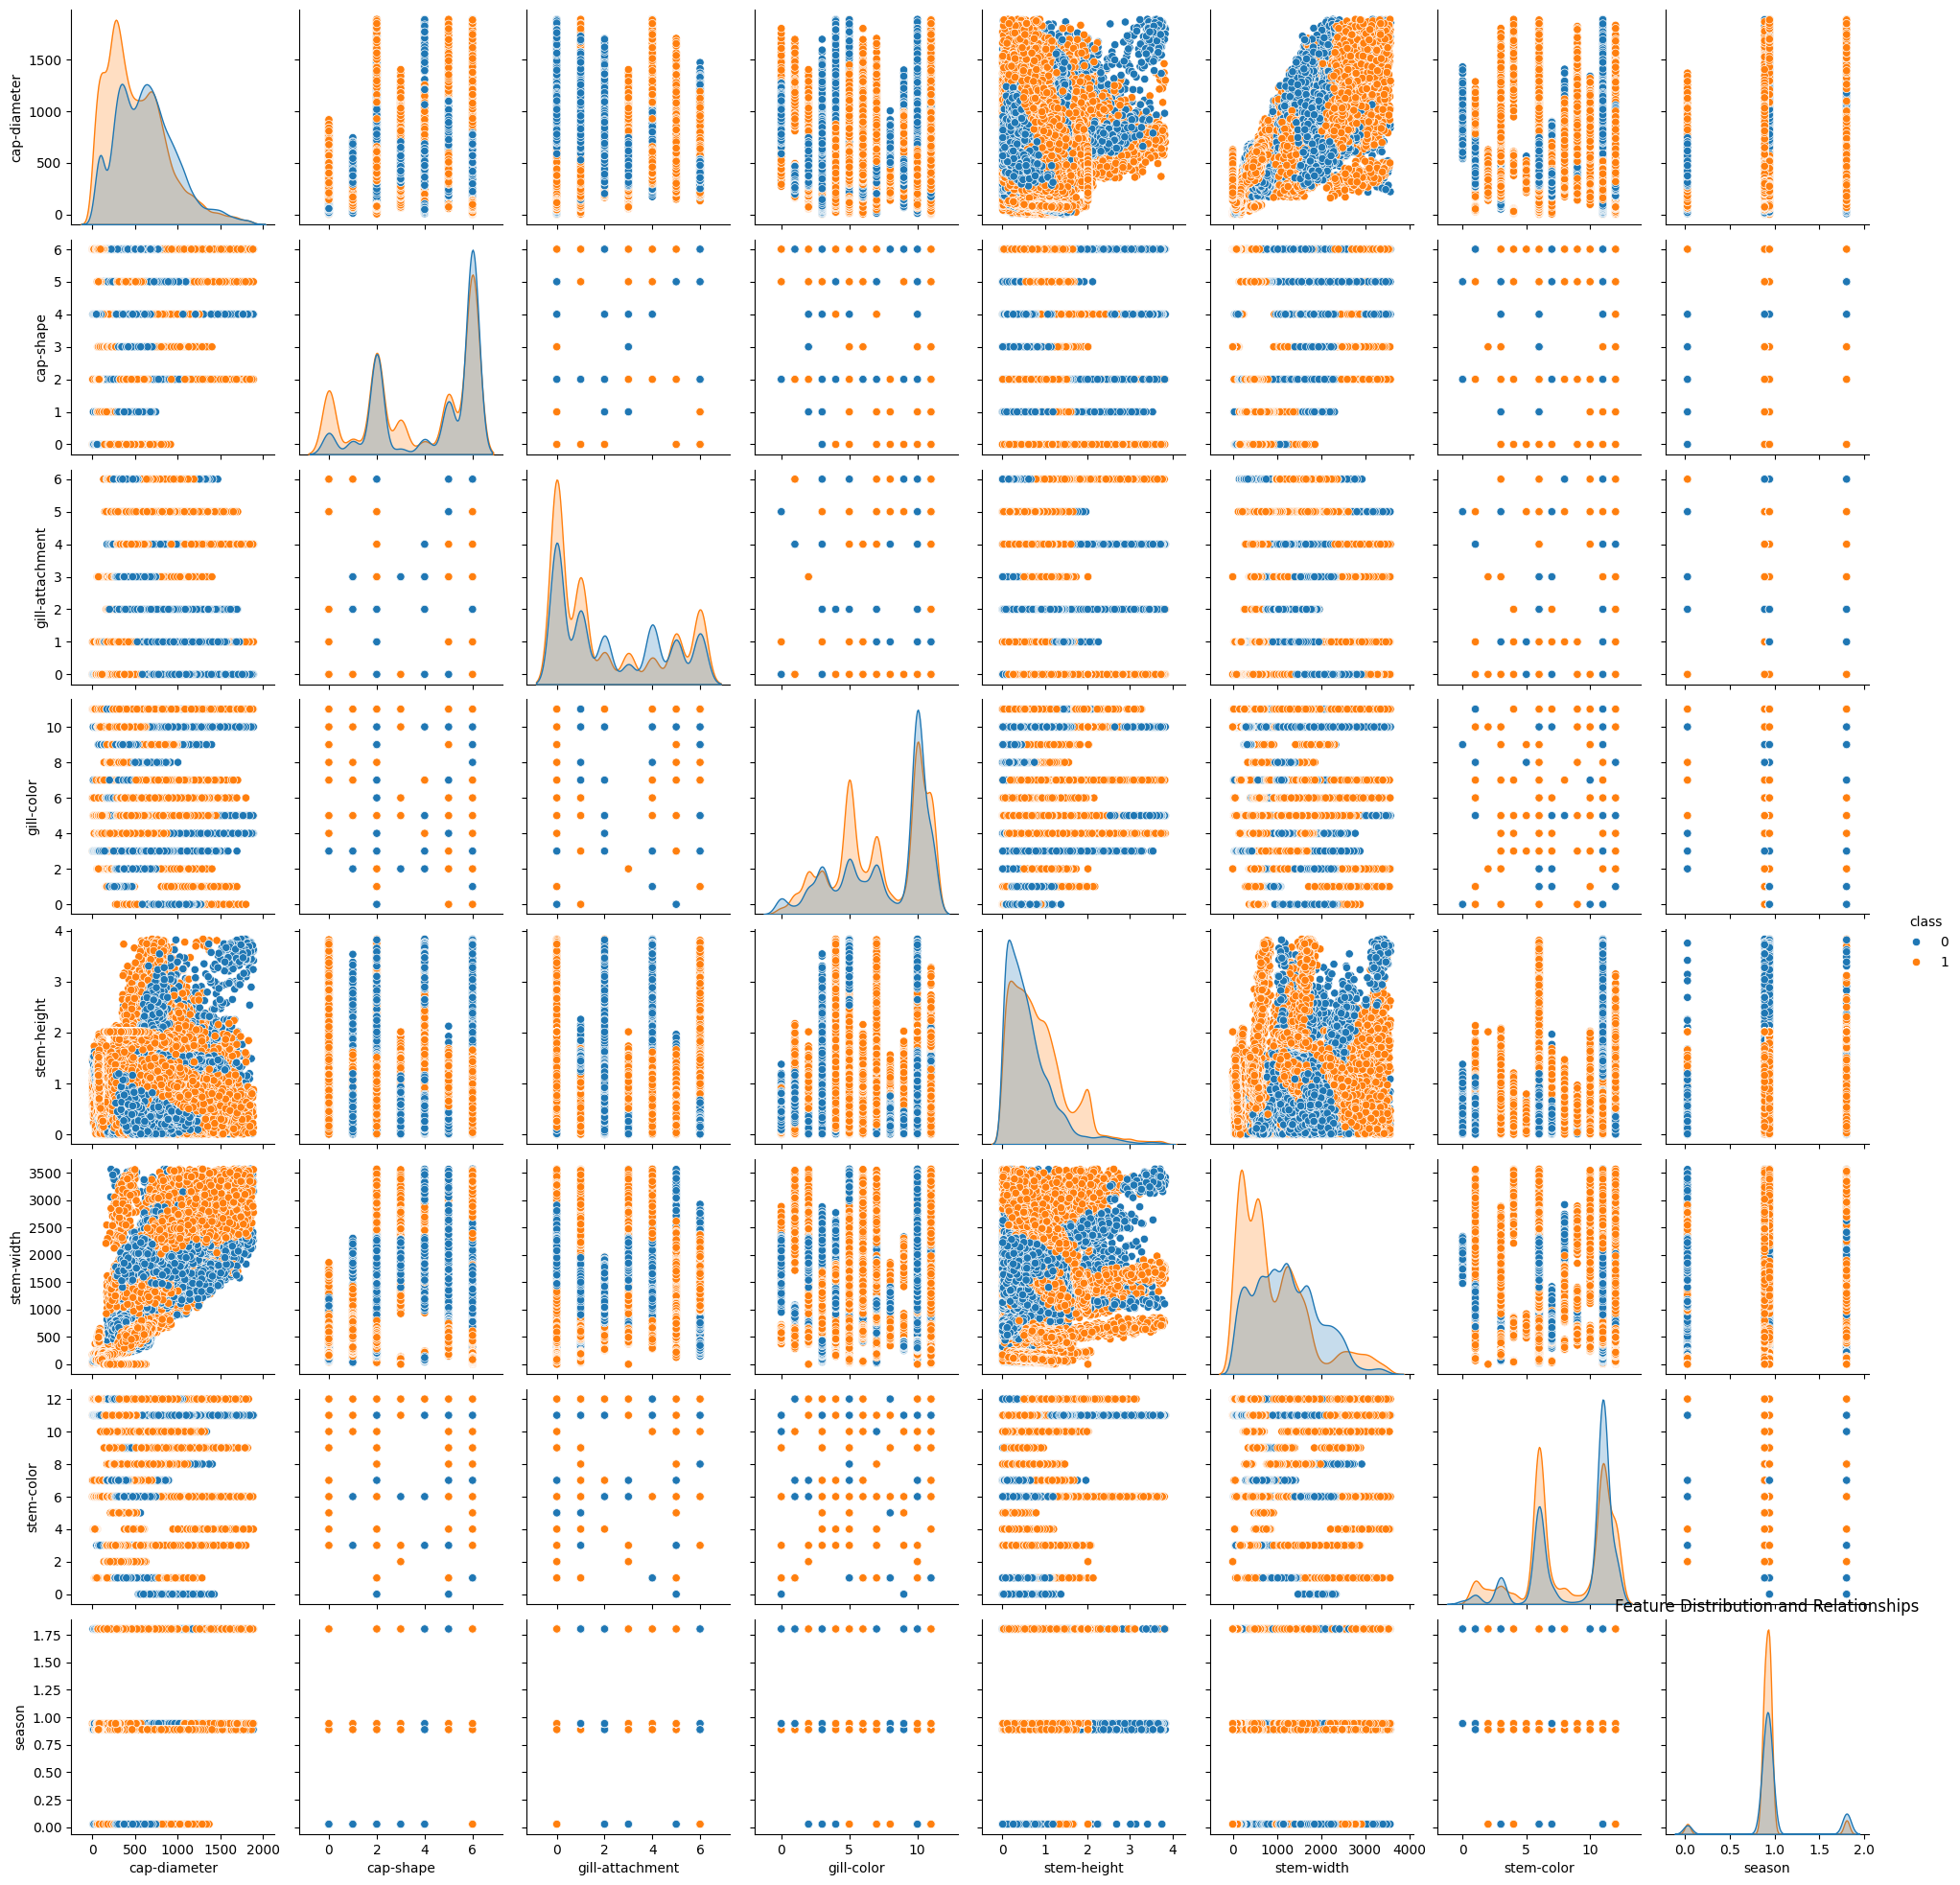

In [ ]:
sns.pairplot(df,hue = 'class')
plt.title('Feature Distribution and Relationships')
plt.show()

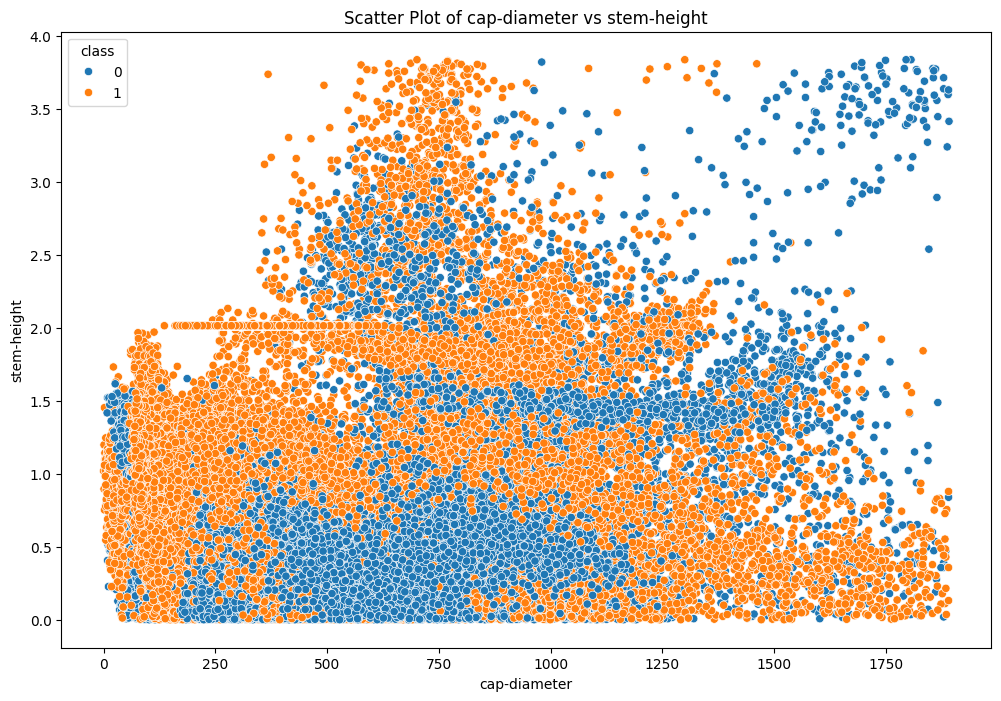

In [ ]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = 'cap-diameter',y = 'stem-height',hue = 'class',data = df)
plt.title('Scatter Plot of cap-diameter vs stem-height')
plt.show()

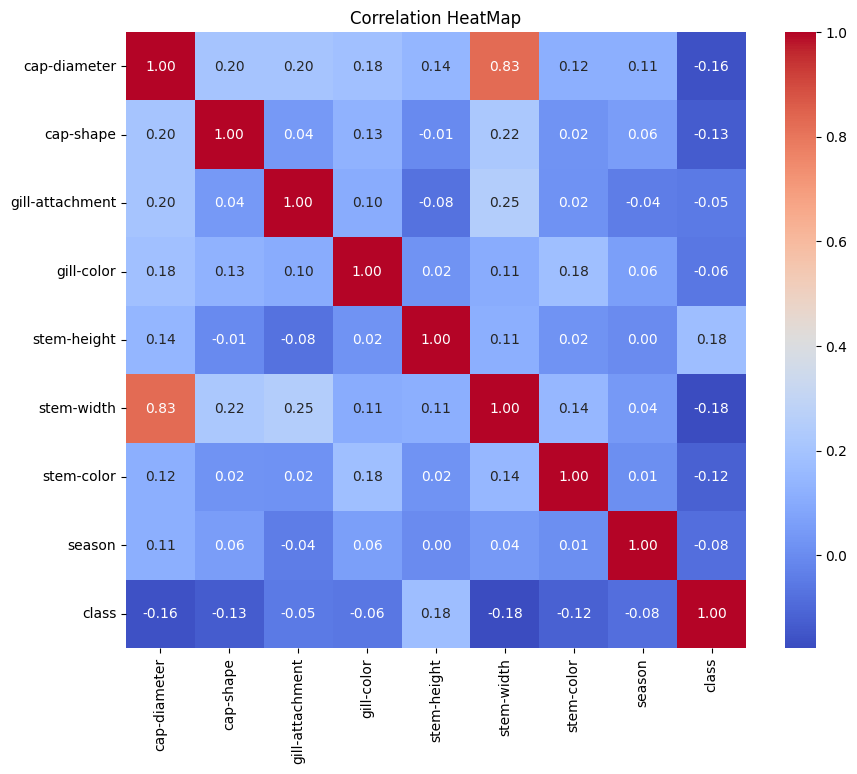

In [ ]:
numeric_cols = df.select_dtypes(include =  np.number).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm',fmt = '.2f')
plt.title('Correlation HeatMap')
plt.show()

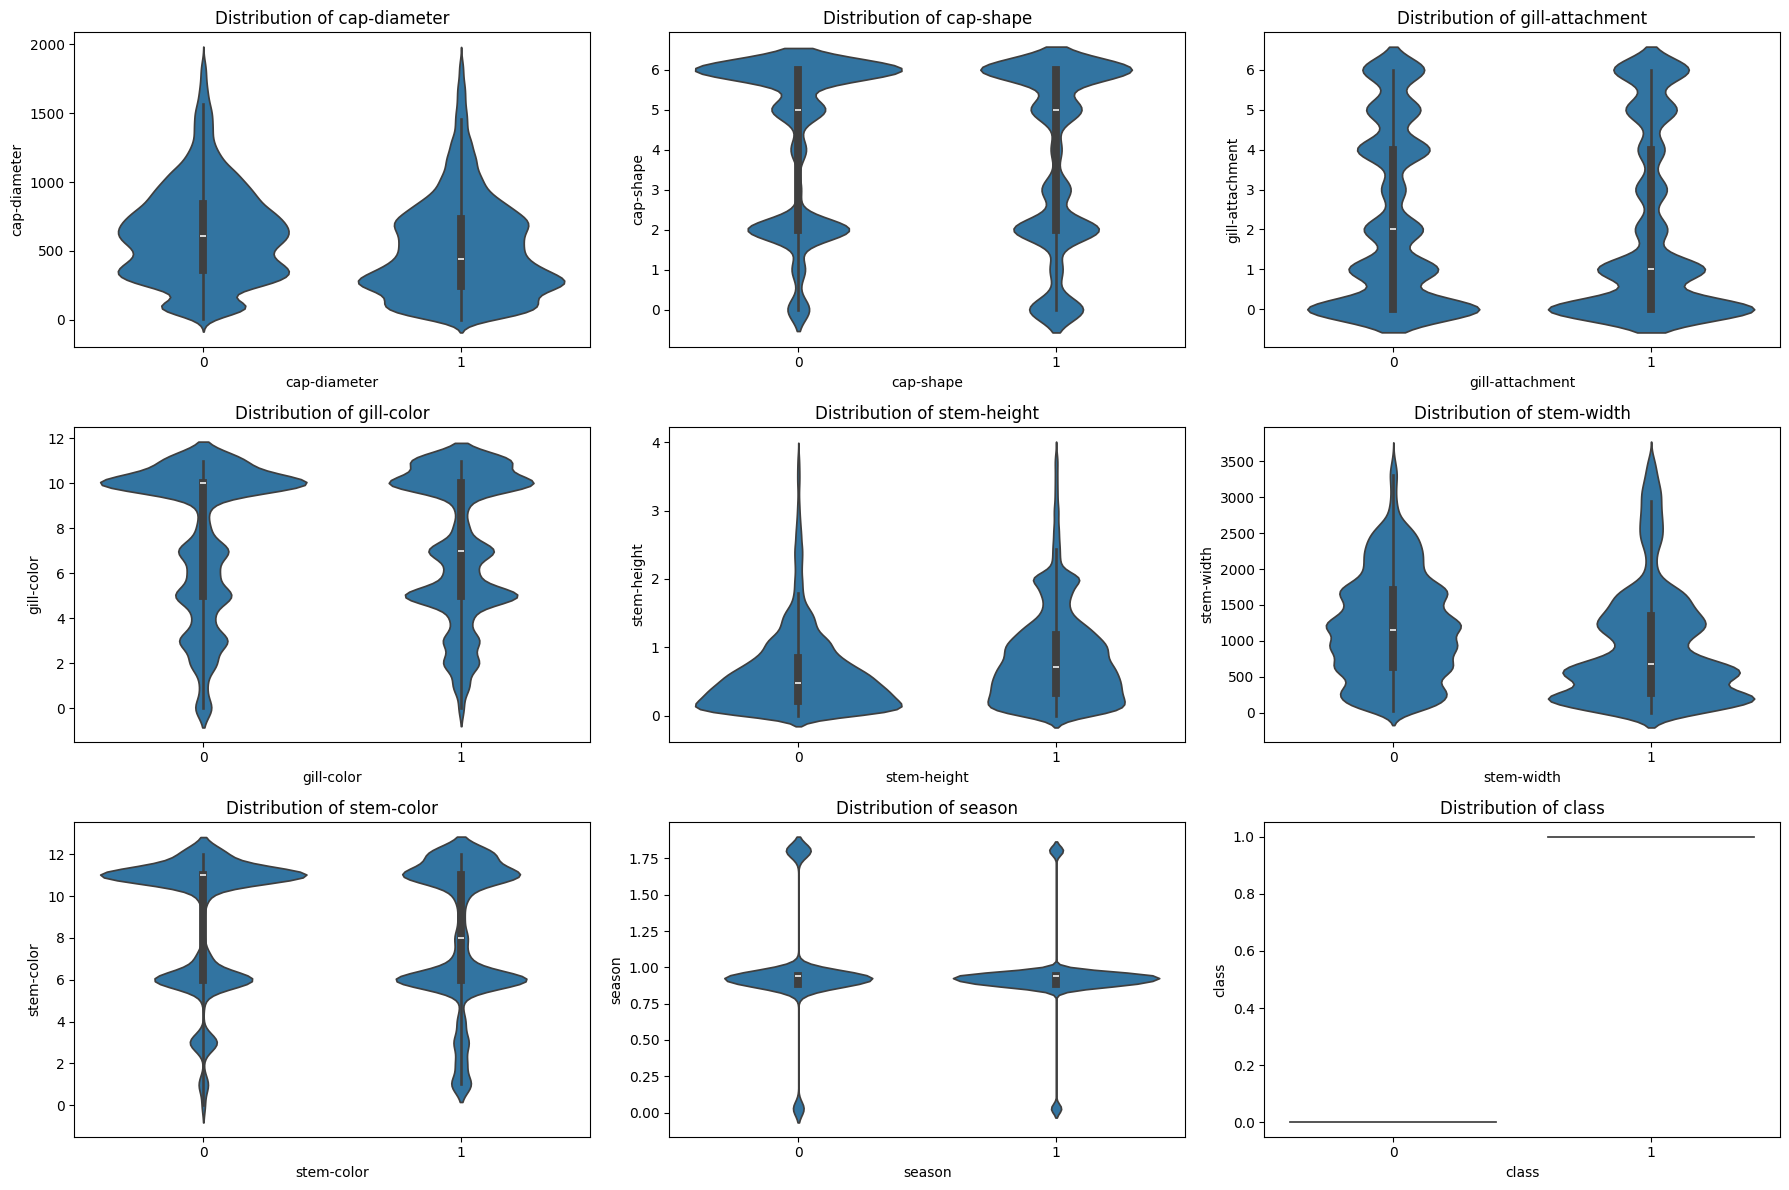

In [ ]:
fig,axes = plt.subplots(3,3,figsize=(18,12))
axes = axes.flatten()

for idx,col in enumerate(df.columns):
    sns.violinplot(data=df,x = 'class', y= col,ax= axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)

for i in range(len(df.columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('class',axis = 1)
Y = df['class']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [ ]:
model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuarcy = accuracy_score(y_test,y_pred)
conf_mat = confusion_matrix(y_test,y_pred)
class_report = classification_report(y_test,y_pred)

print(f'Accuracy: {accuarcy}')
print('Classification Report:')
print(class_report)

Accuracy: 0.6250116311528798
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.54      0.56      4783
           1       0.65      0.69      0.67      5964

    accuracy                           0.63     10747
   macro avg       0.62      0.62      0.62     10747
weighted avg       0.62      0.63      0.62     10747



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


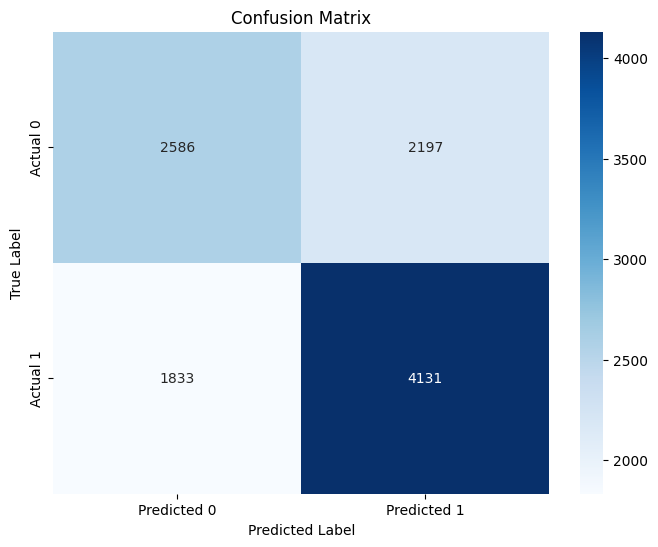

In [ ]:
plt.figure(figsize = (8,6))
sns.heatmap(conf_mat, annot = True,fmt = 'd',cmap = 'Blues',xticklabels = ['Predicted 0','Predicted 1'],yticklabels = ['Actual 0','Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


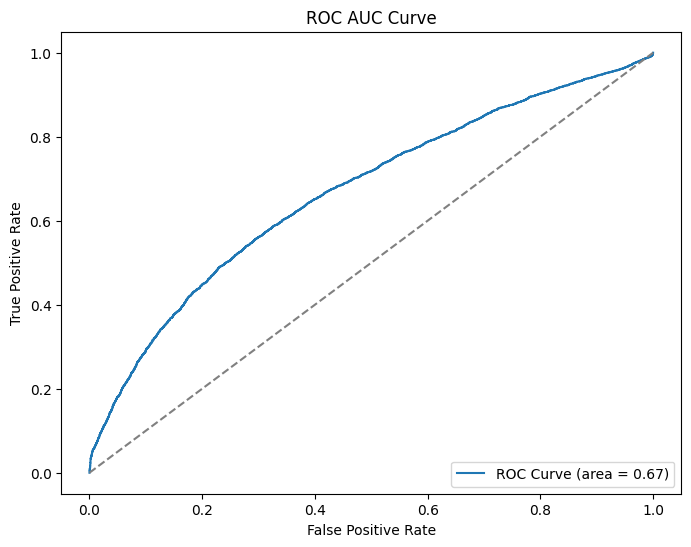

In [ ]:
y_pred_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test,y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize = (8,6))
plt.plot(fpr,tpr,label = f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve")
plt.legend(loc="lower right")
plt.show()

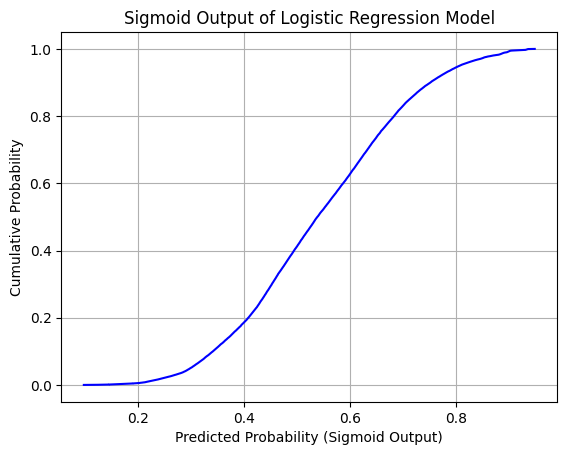

In [ ]:
from sklearn.preprocessing import  StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred_proba = logreg.predict_proba(X_train_scaled)[:, 1]

# Plot the predicted probabilities (which are already the sigmoid values)
plt.plot(np.sort(y_pred_proba), np.linspace(0, 1, len(y_pred_proba)), color='blue')
plt.xlabel('Predicted Probability (Sigmoid Output)')
plt.ylabel('Cumulative Probability')  # A more meaningful y-axis label
plt.title('Sigmoid Output of Logistic Regression Model')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression

class LogitRegression():
  def __init__(self, learning_rate, iterations):
    self.learning_rate = learning_rate
    self.iterations = iterations

  def fit(self,X,Y):
    self.m, self.n = X.shape
    self.W = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    for i in range(self.iterations):
      self.update_weights()
    return self
  def update_weights(self):
    A = 1 / ( 1 + np.exp( - ( self.X.dot( self.W ) + self.b ) ) )
    tmp = ( A - self.Y.T )
    tmp = np.reshape( tmp, self.m )
    dW = np.dot( self.X.T, tmp ) / self.m
    db = np.sum( tmp ) / self.m
    self.W = self.W - self.learning_rate * dW
    self.b = self.b - self.learning_rate * db
    return self

  def predict( self, X ) :
    Z = 1 / ( 1 + np.exp( - ( X.dot( self.W ) + self.b ) ) )
    Y = np.where( Z > 0.5, 1, 0 )
    return Y


def main() :
  data = pd.read_csv('/content/drive/MyDrive/mushroom_cleaned.csv')

  data.drop_duplicates(inplace=True)

  X = data.drop('class', axis=1)
  y = data['class']

  X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=1/3, random_state=0)
  model = LogitRegression( learning_rate = 0.01, iterations = 1000 )

  model.fit( X_train, Y_train )
  model1 = LogisticRegression()
  model1.fit( X_train, Y_train)

    # Prediction on test set
  Y_pred = model.predict( X_test )
  Y_pred1 = model1.predict( X_test )

    # measure performance
  correctly_classified = 0
  correctly_classified1 = 0
  total = len(Y_test) #get the total number of items in y_test, for calculating the accuracy later

  # Iterate through the true and predicted values using zip
  for true_value, pred_value, pred_value1 in zip(Y_test, Y_pred, Y_pred1):
      if true_value == pred_value:
          correctly_classified += 1
      if true_value == pred_value1:
          correctly_classified1 += 1

  print( "Accuracy on test set by our model       :  ", (correctly_classified / total) * 100 )
  print( "Accuracy on test set by sklearn model   :  ", (correctly_classified1 / total ) * 100 )


if __name__ == "__main__" :
    main()

Accuracy on test set by our model       :   54.08966556864496
Accuracy on test set by sklearn model   :   63.145553012115464
